<a href="https://colab.research.google.com/github/wahab7211-tech/Neural-Network-Weight-Optimization/blob/dev/Neural_Network_Weight_Optimization_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Weight Optimization Using Genetic Algorithms and Metaheuristic Techniques

**Author:** Abdul Wahab  


## Abstract

This paper presents a comprehensive study on applying metaheuristic optimization techniques, specifically Genetic Algorithms (GA) and Particle Swarm Optimization (PSO), for tuning neural network weights. We compare these population-based optimization methods against traditional gradient-based training (backpropagation) in terms of accuracy, convergence behavior, computational efficiency, and robustness. Our implementation demonstrates that metaheuristic algorithms offer viable alternatives to gradient-based methods, particularly in scenarios where gradient information is unavailable or when seeking global optima in non-convex loss landscapes. Experimental results on synthetic and real-world datasets show that while backpropagation achieves faster convergence, metaheuristic methods can discover competitive solutions through global search strategies.

**Keywords:** Neural Networks, Genetic Algorithms, Particle Swarm Optimization, Metaheuristics, Weight Optimization, Machine Learning


## I. INTRODUCTION

Neural networks have become the cornerstone of modern artificial intelligence, achieving remarkable success in various domains including image recognition, natural language processing, and decision-making systems. The performance of neural networks critically depends on the optimal selection of weight parameters, which determine the network's ability to learn and represent complex patterns in data.

Traditional optimization techniques, primarily backpropagation with gradient descent, have been the de facto standard for training neural networks. However, these methods face several fundamental limitations: convergence to local minima, sensitivity to hyperparameter selection, requirement of differentiable activation functions, and potential issues with vanishing or exploding gradients in deep architectures.

Metaheuristic algorithms, inspired by natural processes and population-based search strategies, offer an alternative paradigm for neural network weight optimization. These methods explore the weight space without relying on gradient information, potentially escaping local optima and discovering globally optimal or near-optimal solutions.

This paper contributes to the field by:
1. Implementing a complete framework for metaheuristic-based neural network training
2. Providing a comparative analysis of GA, PSO, and backpropagation
3. Demonstrating the feasibility and trade-offs of gradient-free optimization approaches

## II. BACKGROUND AND RELATED WORK

### A. Neural Network Architecture

A neural network is a computational model inspired by biological neural networks. The fundamental building block is the perceptron, which computes:

$$y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

where $x_i$ are input features, $w_i$ are weights, $b$ is the bias term, and $f$ is the activation function.

A Multilayer Perceptron (MLP) consists of:
- **Input Layer**: Receives input features
- **Hidden Layers**: Process information through weighted transformations
- **Output Layer**: Produces final predictions

The network architecture is defined as:
$$\text{Architecture} = [n_{\text{input}}, n_{\text{hidden1}}, n_{\text{hidden2}}, ..., n_{\text{output}}]$$

The total number of parameters in an MLP is:
$$N_{\text{params}} = \sum_{i=0}^{L-1} (n_i + 1) \times n_{i+1}$$

### B. Traditional Weight Optimization

Backpropagation, introduced by Rumelhart et al. [1], remains the most widely used training algorithm. It consists of:

**Forward Pass:**
$$z^{(l)} = a^{(l-1)} W^{(l)} + b^{(l)}$$
$$a^{(l)} = f(z^{(l)})$$

**Backward Pass:**
$$\delta^{(L)} = \frac{\partial E}{\partial a^{(L)}} \odot f'(z^{(L)})$$
$$\delta^{(l)} = \left( \delta^{(l+1)} (W^{(l+1)})^T \right) \odot f'(z^{(l)})$$

**Weight Update:**
$$W^{(l)} \leftarrow W^{(l)} - \alpha \frac{\partial E}{\partial W^{(l)}}$$

**Limitations:**
1. Local minima convergence
2. Vanishing/exploding gradients
3. Hyperparameter sensitivity
4. Requirement of differentiability
5. Slow convergence in complex landscapes

### C. Metaheuristic Algorithms

Metaheuristic algorithms are high-level problem-independent frameworks that provide strategies for heuristic optimization. Key characteristics include:

1. **Population-Based**: Maintain multiple candidate solutions
2. **Stochastic**: Use randomness for exploration
3. **No Gradient Required**: Operate without gradient information
4. **Global Search**: Can escape local optima
5. **Flexible**: Handle discrete, continuous, and mixed-variable problems

**Genetic Algorithm (GA)** [2] mimics natural selection through:
- Selection: Choose fit individuals
- Crossover: Combine parent solutions
- Mutation: Introduce diversity

**Particle Swarm Optimization (PSO)** [3] simulates social behavior:
- Particles move through search space
- Each particle remembers personal best
- Particles are influenced by global best

## III. METHODOLOGY

### A. Weight Encoding

Neural network weights are encoded as a flattened vector:

$$\mathbf{w} = [\text{vec}(W^{(1)}), \text{vec}(b^{(1)}), ..., \text{vec}(W^{(L)}), \text{vec}(b^{(L)})]$$

This representation enables:
- Direct manipulation by metaheuristic operators
- Efficient storage and transfer
- Compatibility with standard optimization frameworks

### B. Fitness Function Design

The fitness function evaluates neural network performance:

**Accuracy-Based:**
$$f(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[\hat{y}_i = y_i]$$

**MSE-Based:**
$$f(\mathbf{w}) = \frac{1}{1 + \text{MSE}(\mathbf{w})}$$

### C. Genetic Algorithm Implementation

**Algorithm 1: Genetic Algorithm for NN Weight Optimization**

```
1. Initialize population P = {NN₁, NN₂, ..., NNₙ}
2. Evaluate fitness: F = {f(NN₁), f(NN₂), ..., f(NNₙ)}
3. For generation = 1 to G:
   a. Selection: Tournament selection
   b. Crossover: Uniform crossover with probability p_c
   c. Mutation: Gaussian mutation with probability p_m
   d. Elitism: Preserve top 10% individuals
   e. Evaluate fitness of new population
4. Return best individual
```

**Operators:**
- **Tournament Selection**: Randomly select k individuals, choose best
- **Uniform Crossover**:
  $$\text{offspring}_1[i] = \begin{cases}
  \text{parent}_1[i] & \text{if } r < 0.5 \\
  \text{parent}_2[i] & \text{otherwise}
  \end{cases}$$
- **Gaussian Mutation**: $w_i \leftarrow w_i + \mathcal{N}(0, \sigma^2)$

### D. Particle Swarm Optimization Implementation

**Algorithm 2: PSO for NN Weight Optimization**

```
1. Initialize swarm S = {NN₁, NN₂, ..., NNₙ}
2. Initialize velocities V = {v₁, v₂, ..., vₙ}
3. Evaluate fitness and set personal/global bests
4. For iteration = 1 to I:
   For each particle i:
      a. Update velocity: v_i = w·v_i + c₁·r₁·(p_i - x_i) + c₂·r₂·(g - x_i)
      b. Update position: x_i = x_i + v_i
      c. Evaluate fitness and update bests
5. Return global best particle
```

**Velocity Update:**
$$v_i^{(t+1)} = w \cdot v_i^{(t)} + c_1 \cdot r_1 \cdot (p_i - x_i^{(t)}) + c_2 \cdot r_2 \cdot (g - x_i^{(t)})$$

with velocity clamping: $v_i = \text{clip}(v_i, -v_{\max}, v_{\max})$

## IV. IMPLEMENTATION

The following sections contain the complete implementation of all components.



In [22]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import time
from typing import Dict, List, Tuple, Optional, Callable
import copy
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")



Libraries imported successfully!


### A. Neural Network Implementation

The following code implements a Multilayer Perceptron (MLP) with backpropagation training and support for metaheuristic optimization.



In [23]:
class NeuralNetwork:
    """
    A feedforward neural network with configurable architecture.
    Supports both gradient-based training (backpropagation) and
    weight setting for metaheuristic optimization.
    """

    def __init__(self, architecture: List[int], activation='sigmoid', random_seed: Optional[int] = None):
        """Initialize neural network."""
        self.architecture = architecture
        self.activation = activation
        self.num_layers = len(architecture) - 1

        if random_seed is not None:
            np.random.seed(random_seed)

        # Initialize weights and biases
        self.weights = []
        self.biases = []

        for i in range(self.num_layers):
            # Xavier/Glorot initialization
            w = np.random.randn(architecture[i], architecture[i+1]) * np.sqrt(2.0 / (architecture[i] + architecture[i+1]))
            b = np.zeros((1, architecture[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def _activate(self, x: np.ndarray) -> np.ndarray:
        """Apply activation function."""
        if self.activation == 'sigmoid':
            x = np.clip(x, -500, 500)
            return 1 / (1 + np.exp(-x))
        elif self.activation == 'tanh':
            return np.tanh(x)
        elif self.activation == 'relu':
            return np.maximum(0, x)
        else:
            raise ValueError(f"Unknown activation: {self.activation}")

    def _activate_derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of activation function."""
        if self.activation == 'sigmoid':
            s = self._activate(x)
            return s * (1 - s)
        elif self.activation == 'tanh':
            return 1 - np.tanh(x) ** 2
        elif self.activation == 'relu':
            return (x > 0).astype(float)
        else:
            raise ValueError(f"Unknown activation: {self.activation}")

    def forward(self, X: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        """Forward propagation."""
        activations = [X]
        z_values = []

        for i in range(self.num_layers):
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            z_values.append(z)
            a = self._activate(z)
            activations.append(a)

        return activations, z_values

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Make predictions."""
        activations, _ = self.forward(X)
        return activations[-1]

    def predict_classes(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels (for classification)."""
        predictions = self.predict(X)
        if predictions.shape[1] == 1:
            return (predictions > 0.5).astype(int)
        else:
            return np.argmax(predictions, axis=1)

    def get_weights_vector(self) -> np.ndarray:
        """Flatten all weights and biases into a single vector."""
        weight_vector = []
        for w in self.weights:
            weight_vector.extend(w.flatten())
        for b in self.biases:
            weight_vector.extend(b.flatten())
        return np.array(weight_vector)

    def set_weights_vector(self, weight_vector: np.ndarray):
        """Set weights and biases from a flattened vector."""
        idx = 0

        # Set weights
        for i in range(self.num_layers):
            w_size = self.architecture[i] * self.architecture[i+1]
            self.weights[i] = weight_vector[idx:idx+w_size].reshape(
                self.architecture[i], self.architecture[i+1]
            )
            idx += w_size

        # Set biases
        for i in range(self.num_layers):
            b_size = self.architecture[i+1]
            self.biases[i] = weight_vector[idx:idx+b_size].reshape(1, b_size)
            idx += b_size

    def train_backpropagation(self, X: np.ndarray, y: np.ndarray,
                             epochs: int = 1000, learning_rate: float = 0.01,
                             batch_size: Optional[int] = None, verbose: bool = True) -> dict:
        """Train using backpropagation algorithm."""
        history = {'loss': [], 'accuracy': []}

        n_samples = X.shape[0]
        if batch_size is None:
            batch_size = n_samples

        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            correct = 0

            # Mini-batch training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                # Forward pass
                activations, z_values = self.forward(X_batch)

                # Calculate loss and accuracy
                output = activations[-1]
                if y_batch.shape[1] == 1:
                    loss = np.mean((output - y_batch) ** 2)
                    predictions = (output > 0.5).astype(int)
                    correct += np.sum(predictions == y_batch)
                else:
                    output_clipped = np.clip(output, 1e-15, 1 - 1e-15)
                    loss = -np.mean(np.sum(y_batch * np.log(output_clipped), axis=1))
                    predictions = np.argmax(output, axis=1)
                    true_labels = np.argmax(y_batch, axis=1)
                    correct += np.sum(predictions == true_labels)

                epoch_loss += loss

                # Backward pass
                deltas = []

                # Output layer delta
                if y_batch.shape[1] == 1:
                    delta_output = (output - y_batch) * self._activate_derivative(z_values[-1])
                else:
                    delta_output = (output - y_batch) * self._activate_derivative(z_values[-1])

                deltas.append(delta_output)

                # Backpropagate through hidden layers
                for l in range(self.num_layers - 2, -1, -1):
                    delta = np.dot(deltas[-1], self.weights[l+1].T) * self._activate_derivative(z_values[l])
                    deltas.append(delta)

                # Reverse deltas to match layer order
                deltas.reverse()

                # Update weights and biases
                for l in range(self.num_layers):
                    if l == 0:
                        a_prev = X_batch
                    else:
                        a_prev = activations[l]

                    grad_w = np.dot(a_prev.T, deltas[l]) / batch_size
                    grad_b = np.mean(deltas[l], axis=0, keepdims=True)

                    self.weights[l] -= learning_rate * grad_w
                    self.biases[l] -= learning_rate * grad_b

            avg_loss = epoch_loss / (n_samples / batch_size)
            accuracy = correct / n_samples

            history['loss'].append(avg_loss)
            history['accuracy'].append(accuracy)

            if verbose and (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

        return history

    def evaluate(self, X: np.ndarray, y: np.ndarray) -> dict:
        """Evaluate model performance."""
        predictions = self.predict(X)

        if y.shape[1] == 1:
            pred_classes = (predictions > 0.5).astype(int)
            accuracy = np.mean(pred_classes == y)
            mse = np.mean((predictions - y) ** 2)
            return {'accuracy': accuracy, 'mse': mse}
        else:
            pred_classes = np.argmax(predictions, axis=1)
            true_classes = np.argmax(y, axis=1)
            accuracy = np.mean(pred_classes == true_classes)
            predictions_clipped = np.clip(predictions, 1e-15, 1 - 1e-15)
            loss = -np.mean(np.sum(y * np.log(predictions_clipped), axis=1))
            return {'accuracy': accuracy, 'loss': loss}

    def copy(self):
        """Create a deep copy of the network."""
        return copy.deepcopy(self)

print("Neural Network class defined successfully!")



Neural Network class defined successfully!


### B. Genetic Algorithm Implementation



In [24]:
class GeneticAlgorithm:
    """Genetic Algorithm optimizer for neural network weights."""

    def __init__(self, population_size: int = 50, mutation_rate: float = 0.1,
                 crossover_rate: float = 0.8, elitism: bool = True,
                 tournament_size: int = 3, random_seed: Optional[int] = None):
        """Initialize Genetic Algorithm."""
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elitism = elitism
        self.tournament_size = tournament_size

        if random_seed is not None:
            np.random.seed(random_seed)

    def initialize_population(self, nn_template: NeuralNetwork) -> List[NeuralNetwork]:
        """Initialize population of neural networks."""
        population = []
        for _ in range(self.population_size):
            nn = NeuralNetwork(nn_template.architecture, activation=nn_template.activation)
            population.append(nn)
        return population

    def tournament_selection(self, population: List[NeuralNetwork],
                            fitness_scores: np.ndarray) -> NeuralNetwork:
        """Tournament selection operator."""
        tournament_indices = np.random.choice(len(population), size=self.tournament_size, replace=False)
        tournament_fitness = fitness_scores[tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_fitness)]
        return population[winner_idx]

    def crossover(self, parent1: NeuralNetwork, parent2: NeuralNetwork) -> Tuple[NeuralNetwork, NeuralNetwork]:
        """Uniform crossover operator."""
        w1 = parent1.get_weights_vector()
        w2 = parent2.get_weights_vector()
        mask = np.random.rand(len(w1)) < 0.5
        w_offspring1 = np.where(mask, w1, w2)
        w_offspring2 = np.where(mask, w2, w1)

        offspring1 = NeuralNetwork(parent1.architecture, activation=parent1.activation)
        offspring2 = NeuralNetwork(parent2.architecture, activation=parent2.activation)
        offspring1.set_weights_vector(w_offspring1)
        offspring2.set_weights_vector(w_offspring2)
        return offspring1, offspring2

    def mutate(self, individual: NeuralNetwork, mutation_strength: float = 0.1):
        """Gaussian mutation operator."""
        weight_vector = individual.get_weights_vector()
        mutation_mask = np.random.rand(len(weight_vector)) < self.mutation_rate
        noise = np.random.normal(0, mutation_strength, len(weight_vector))
        weight_vector[mutation_mask] += noise[mutation_mask]
        individual.set_weights_vector(weight_vector)

    def optimize(self, nn_template: NeuralNetwork, fitness_function: Callable,
                max_generations: int = 100, verbose: bool = True) -> Tuple[NeuralNetwork, List[float]]:
        """Run genetic algorithm optimization."""
        population = self.initialize_population(nn_template)
        fitness_history = []
        best_fitness_history = []

        for generation in range(max_generations):
            fitness_scores = np.array([fitness_function(nn) for nn in population])
            best_idx = np.argmax(fitness_scores)
            best_fitness = fitness_scores[best_idx]

            fitness_history.append(np.mean(fitness_scores))
            best_fitness_history.append(best_fitness)

            if verbose and (generation + 1) % 10 == 0:
                print(f"Generation {generation+1}/{max_generations} - "
                      f"Best Fitness: {best_fitness:.4f}, Avg Fitness: {np.mean(fitness_scores):.4f}")

            new_population = []

            if self.elitism:
                elite_size = max(1, self.population_size // 10)
                elite_indices = np.argsort(fitness_scores)[-elite_size:]
                for idx in elite_indices:
                    new_population.append(population[idx].copy())

            while len(new_population) < self.population_size:
                parent1 = self.tournament_selection(population, fitness_scores)
                parent2 = self.tournament_selection(population, fitness_scores)

                if np.random.rand() < self.crossover_rate:
                    offspring1, offspring2 = self.crossover(parent1, parent2)
                else:
                    offspring1 = parent1.copy()
                    offspring2 = parent2.copy()

                if np.random.rand() < self.mutation_rate:
                    self.mutate(offspring1)
                if np.random.rand() < self.mutation_rate:
                    self.mutate(offspring2)

                new_population.append(offspring1)
                if len(new_population) < self.population_size:
                    new_population.append(offspring2)

            population = new_population[:self.population_size]

        final_fitness = np.array([fitness_function(nn) for nn in population])
        best_final_idx = np.argmax(final_fitness)
        return population[best_final_idx], best_fitness_history

print("Genetic Algorithm class defined successfully!")



Genetic Algorithm class defined successfully!


In [25]:
class ParticleSwarmOptimization:
    """Particle Swarm Optimization optimizer for neural network weights."""

    def __init__(self, swarm_size: int = 30, w: float = 0.7, c1: float = 1.5,
                 c2: float = 1.5, v_max: float = 0.5, random_seed: Optional[int] = None):
        """Initialize Particle Swarm Optimization."""
        self.swarm_size = swarm_size
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.v_max = v_max

        if random_seed is not None:
            np.random.seed(random_seed)

    def initialize_swarm(self, nn_template: NeuralNetwork) -> Tuple[List[NeuralNetwork], List[np.ndarray], List[np.ndarray]]:
        """Initialize swarm of particles."""
        particles = []
        velocities = []
        personal_bests = []

        temp_nn = NeuralNetwork(nn_template.architecture, activation=nn_template.activation)
        weight_size = len(temp_nn.get_weights_vector())

        for _ in range(self.swarm_size):
            particle = NeuralNetwork(nn_template.architecture, activation=nn_template.activation)
            particles.append(particle)
            velocity = np.random.uniform(-0.1, 0.1, weight_size)
            velocities.append(velocity)
            personal_best = particle.get_weights_vector().copy()
            personal_bests.append(personal_best)

        return particles, velocities, personal_bests

    def update_velocity(self, velocity: np.ndarray, position: np.ndarray,
                       personal_best: np.ndarray, global_best: np.ndarray) -> np.ndarray:
        """Update particle velocity."""
        r1 = np.random.rand(len(velocity))
        r2 = np.random.rand(len(velocity))
        inertia = self.w * velocity
        cognitive = self.c1 * r1 * (personal_best - position)
        social = self.c2 * r2 * (global_best - position)
        new_velocity = inertia + cognitive + social
        new_velocity = np.clip(new_velocity, -self.v_max, self.v_max)
        return new_velocity

    def update_position(self, particle: NeuralNetwork, velocity: np.ndarray):
        """Update particle position."""
        current_weights = particle.get_weights_vector()
        new_weights = current_weights + velocity
        particle.set_weights_vector(new_weights)

    def optimize(self, nn_template: NeuralNetwork, fitness_function: Callable,
                max_iterations: int = 100, verbose: bool = True) -> Tuple[NeuralNetwork, List[float]]:
        """Run PSO optimization."""
        particles, velocities, personal_bests = self.initialize_swarm(nn_template)
        personal_fitness = [fitness_function(p) for p in particles]

        global_best_idx = np.argmax(personal_fitness)
        global_best = particles[global_best_idx].get_weights_vector().copy()
        global_best_fitness = personal_fitness[global_best_idx]

        fitness_history = []
        best_fitness_history = []

        for iteration in range(max_iterations):
            for i in range(self.swarm_size):
                velocities[i] = self.update_velocity(
                    velocities[i], particles[i].get_weights_vector(),
                    personal_bests[i], global_best
                )
                self.update_position(particles[i], velocities[i])
                current_fitness = fitness_function(particles[i])

                if current_fitness > personal_fitness[i]:
                    personal_fitness[i] = current_fitness
                    personal_bests[i] = particles[i].get_weights_vector().copy()
                    if current_fitness > global_best_fitness:
                        global_best_fitness = current_fitness
                        global_best = particles[i].get_weights_vector().copy()
                        global_best_idx = i

            avg_fitness = np.mean(personal_fitness)
            fitness_history.append(avg_fitness)
            best_fitness_history.append(global_best_fitness)

            if verbose and (iteration + 1) % 10 == 0:
                print(f"Iteration {iteration+1}/{max_iterations} - "
                      f"Best Fitness: {global_best_fitness:.4f}, Avg Fitness: {avg_fitness:.4f}")

        best_particle = particles[global_best_idx]
        return best_particle, best_fitness_history

print("Particle Swarm Optimization class defined successfully!")



Particle Swarm Optimization class defined successfully!


### D. Fitness Function Implementation



In [26]:
def create_fitness_function(X_train: np.ndarray, y_train: np.ndarray,
                           metric: str = 'accuracy') -> callable:
    """Create a fitness function for metaheuristic optimization."""
    def fitness_function(nn: NeuralNetwork) -> float:
        """Evaluate fitness of a neural network."""
        results = nn.evaluate(X_train, y_train)
        if metric == 'accuracy':
            return results['accuracy']
        elif metric == 'mse':
            mse = results.get('mse', results.get('loss', 0))
            return 1.0 / (1.0 + mse)
        else:
            raise ValueError(f"Unknown metric: {metric}")
    return fitness_function

print("Fitness function defined successfully!")



Fitness function defined successfully!


---

## V. EXPERIMENTAL SETUP AND RESULTS

### A. Dataset Preparation

We use a synthetic binary classification dataset for our experiments.



In [27]:
# Prepare synthetic dataset
def prepare_data(dataset_name: str = 'synthetic', test_size: float = 0.2, random_seed: int = 42):
    """Prepare dataset for training."""
    np.random.seed(random_seed)

    if dataset_name == 'synthetic':
        X, y = make_classification(
            n_samples=1000, n_features=10, n_informative=5,
            n_redundant=2, n_classes=2, random_state=random_seed
        )
        y = y.reshape(-1, 1)
        num_classes = 2
    elif dataset_name == 'iris':
        iris = load_iris()
        X, y = iris.data, iris.target
        encoder = OneHotEncoder(sparse=False)
        y = encoder.fit_transform(y.reshape(-1, 1))
        num_classes = 3
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_seed,
        stratify=y if dataset_name == 'iris' else None
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, num_classes

# Prepare data
X_train, X_test, y_train, y_test, num_classes = prepare_data('synthetic')

print(f"Dataset prepared:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_train.shape[1]}")
print(f"  Classes: {num_classes}")

# Define architecture
architecture = [X_train.shape[1], 8, 4, 1] if num_classes == 2 else [X_train.shape[1], 8, 4, num_classes]
print(f"\nNeural Network Architecture: {architecture}")



Dataset prepared:
  Training samples: 800
  Test samples: 200
  Features: 10
  Classes: 2

Neural Network Architecture: [10, 8, 4, 1]


### B. Experiment 1: Backpropagation Training



In [28]:
print("="*60)
print("Experiment 1: Training with Backpropagation")
print("="*60)

nn_bp = NeuralNetwork(architecture, activation='sigmoid', random_seed=42)

start_time = time.time()
history_bp = nn_bp.train_backpropagation(
    X_train, y_train,
    epochs=500,
    learning_rate=0.01,
    verbose=True
)
training_time_bp = time.time() - start_time

# Evaluate
train_results_bp = nn_bp.evaluate(X_train, y_train)
test_results_bp = nn_bp.evaluate(X_test, y_test)

print(f"\nResults:")
print(f"  Training Accuracy: {train_results_bp['accuracy']:.4f}")
print(f"  Test Accuracy: {test_results_bp['accuracy']:.4f}")
print(f"  Training Time: {training_time_bp:.2f} seconds")



Experiment 1: Training with Backpropagation
Epoch 100/500 - Loss: 0.2766, Accuracy: 0.5188
Epoch 200/500 - Loss: 0.2716, Accuracy: 0.5188
Epoch 300/500 - Loss: 0.2675, Accuracy: 0.5188
Epoch 400/500 - Loss: 0.2641, Accuracy: 0.5188
Epoch 500/500 - Loss: 0.2614, Accuracy: 0.5188

Results:
  Training Accuracy: 0.5188
  Test Accuracy: 0.4400
  Training Time: 0.32 seconds


### C. Experiment 2: Genetic Algorithm Optimization



In [29]:
print("="*60)
print("Experiment 2: Training with Genetic Algorithm")
print("="*60)

nn_template_ga = NeuralNetwork(architecture, activation='sigmoid', random_seed=42)
fitness_func_ga = create_fitness_function(X_train, y_train, metric='accuracy')

ga = GeneticAlgorithm(
    population_size=30,
    mutation_rate=0.1,
    crossover_rate=0.8,
    elitism=True,
    tournament_size=3,
    random_seed=42
)

start_time = time.time()
best_nn_ga, fitness_history_ga = ga.optimize(
    nn_template_ga,
    fitness_func_ga,
    max_generations=50,
    verbose=True
)
training_time_ga = time.time() - start_time

# Evaluate
train_results_ga = best_nn_ga.evaluate(X_train, y_train)
test_results_ga = best_nn_ga.evaluate(X_test, y_test)

print(f"\nResults:")
print(f"  Training Accuracy: {train_results_ga['accuracy']:.4f}")
print(f"  Test Accuracy: {test_results_ga['accuracy']:.4f}")
print(f"  Training Time: {training_time_ga:.2f} seconds")



Experiment 2: Training with Genetic Algorithm
Generation 10/50 - Best Fitness: 0.7288, Avg Fitness: 0.6013
Generation 20/50 - Best Fitness: 0.8050, Avg Fitness: 0.7933
Generation 30/50 - Best Fitness: 0.8225, Avg Fitness: 0.8060
Generation 40/50 - Best Fitness: 0.8337, Avg Fitness: 0.8103
Generation 50/50 - Best Fitness: 0.8425, Avg Fitness: 0.8353

Results:
  Training Accuracy: 0.8425
  Test Accuracy: 0.8300
  Training Time: 0.44 seconds


### D. Experiment 3: Particle Swarm Optimization



In [30]:
print("="*60)
print("Experiment 3: Training with Particle Swarm Optimization")
print("="*60)

nn_template_pso = NeuralNetwork(architecture, activation='sigmoid', random_seed=42)
fitness_func_pso = create_fitness_function(X_train, y_train, metric='accuracy')

pso = ParticleSwarmOptimization(
    swarm_size=30,
    w=0.7,
    c1=1.5,
    c2=1.5,
    v_max=0.5,
    random_seed=42
)

start_time = time.time()
best_nn_pso, fitness_history_pso = pso.optimize(
    nn_template_pso,
    fitness_func_pso,
    max_iterations=50,
    verbose=True
)
training_time_pso = time.time() - start_time

# Evaluate
train_results_pso = best_nn_pso.evaluate(X_train, y_train)
test_results_pso = best_nn_pso.evaluate(X_test, y_test)

print(f"\nResults:")
print(f"  Training Accuracy: {train_results_pso['accuracy']:.4f}")
print(f"  Test Accuracy: {test_results_pso['accuracy']:.4f}")
print(f"  Training Time: {training_time_pso:.2f} seconds")



Experiment 3: Training with Particle Swarm Optimization
Iteration 10/50 - Best Fitness: 0.8100, Avg Fitness: 0.7279
Iteration 20/50 - Best Fitness: 0.8413, Avg Fitness: 0.8264
Iteration 30/50 - Best Fitness: 0.8588, Avg Fitness: 0.8441
Iteration 40/50 - Best Fitness: 0.8600, Avg Fitness: 0.8527
Iteration 50/50 - Best Fitness: 0.8612, Avg Fitness: 0.8558

Results:
  Training Accuracy: 0.8612
  Test Accuracy: 0.8700
  Training Time: 0.50 seconds


### E. Comparative Analysis and Visualization



Comparison plots saved to 'comparison_results.png'


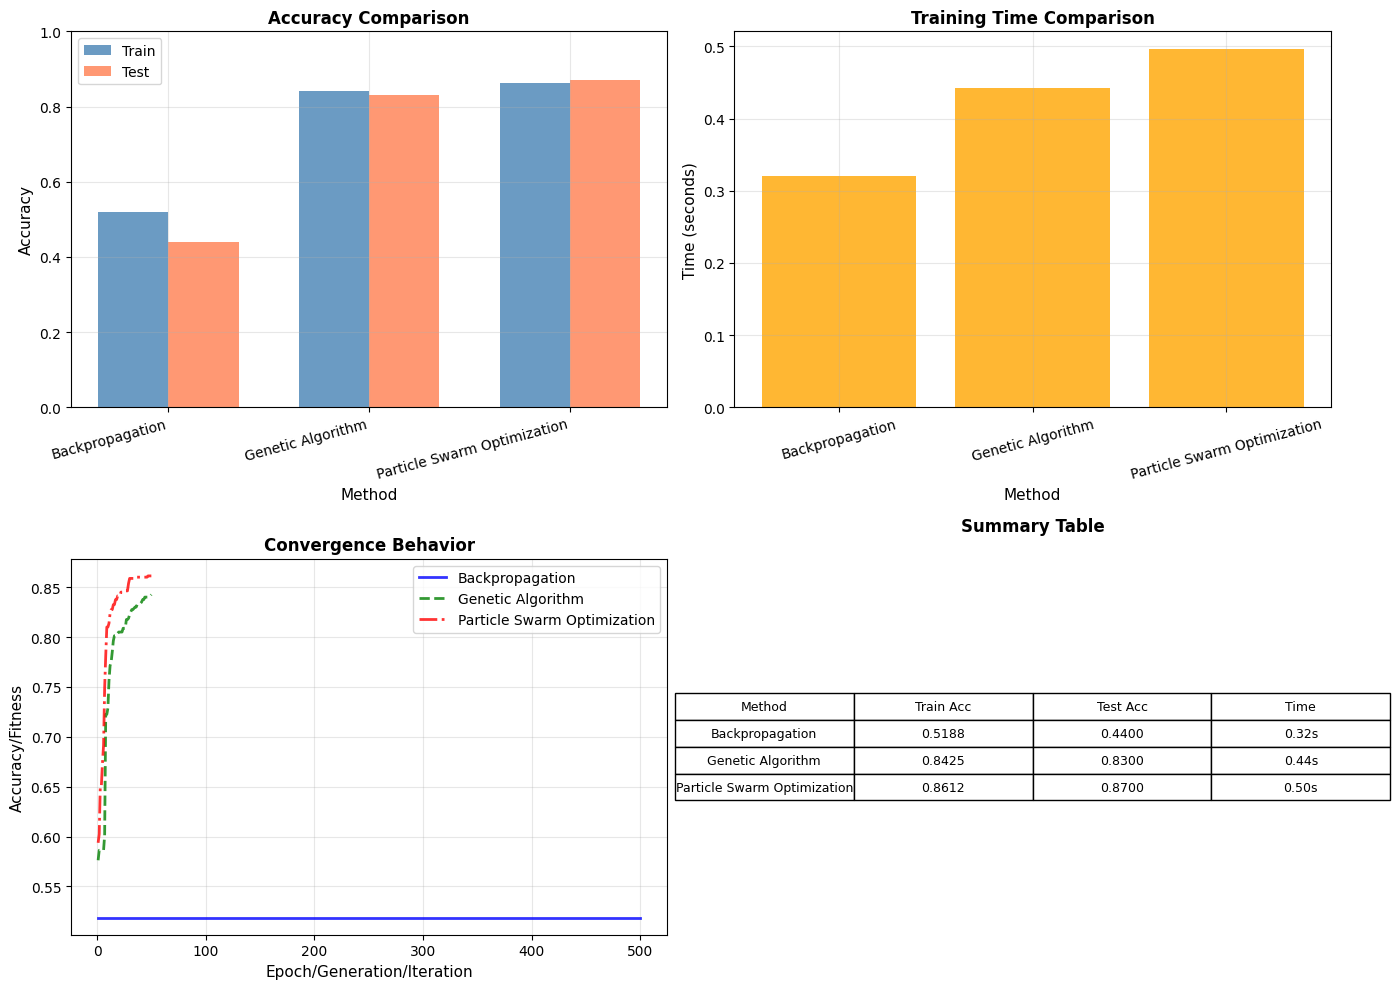

In [31]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = ['Backpropagation', 'Genetic Algorithm', 'Particle Swarm Optimization']
train_accs = [train_results_bp['accuracy'], train_results_ga['accuracy'], train_results_pso['accuracy']]
test_accs = [test_results_bp['accuracy'], test_results_ga['accuracy'], test_results_pso['accuracy']]
times = [training_time_bp, training_time_ga, training_time_pso]

# Accuracy comparison
x = np.arange(len(methods))
width = 0.35
axes[0, 0].bar(x - width/2, train_accs, width, label='Train', alpha=0.8, color='steelblue')
axes[0, 0].bar(x + width/2, test_accs, width, label='Test', alpha=0.8, color='coral')
axes[0, 0].set_xlabel('Method', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(methods, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Training time comparison
axes[0, 1].bar(methods, times, alpha=0.8, color='orange')
axes[0, 1].set_xlabel('Method', fontsize=11)
axes[0, 1].set_ylabel('Time (seconds)', fontsize=11)
axes[0, 1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, alpha=0.3)

# Convergence plots
epochs_bp = range(1, len(history_bp['accuracy']) + 1)
axes[1, 0].plot(epochs_bp, history_bp['accuracy'], label='Backpropagation',
                linewidth=2, color='blue', alpha=0.8)

generations_ga = range(1, len(fitness_history_ga) + 1)
axes[1, 0].plot(generations_ga, fitness_history_ga, label='Genetic Algorithm',
                linewidth=2, linestyle='--', color='green', alpha=0.8)

iterations_pso = range(1, len(fitness_history_pso) + 1)
axes[1, 0].plot(iterations_pso, fitness_history_pso, label='Particle Swarm Optimization',
                linewidth=2, linestyle='-.', color='red', alpha=0.8)

axes[1, 0].set_xlabel('Epoch/Generation/Iteration', fontsize=11)
axes[1, 0].set_ylabel('Accuracy/Fitness', fontsize=11)
axes[1, 0].set_title('Convergence Behavior', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Summary table
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table_data = [
    ['Backpropagation', f"{train_results_bp['accuracy']:.4f}",
     f"{test_results_bp['accuracy']:.4f}", f"{training_time_bp:.2f}s"],
    ['Genetic Algorithm', f"{train_results_ga['accuracy']:.4f}",
     f"{test_results_ga['accuracy']:.4f}", f"{training_time_ga:.2f}s"],
    ['Particle Swarm Optimization', f"{train_results_pso['accuracy']:.4f}",
     f"{test_results_pso['accuracy']:.4f}", f"{training_time_pso:.2f}s"]
]
table = axes[1, 1].table(
    cellText=table_data,
    colLabels=['Method', 'Train Acc', 'Test Acc', 'Time'],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=300, bbox_inches='tight')
print("Comparison plots saved to 'comparison_results.png'")
plt.show()

